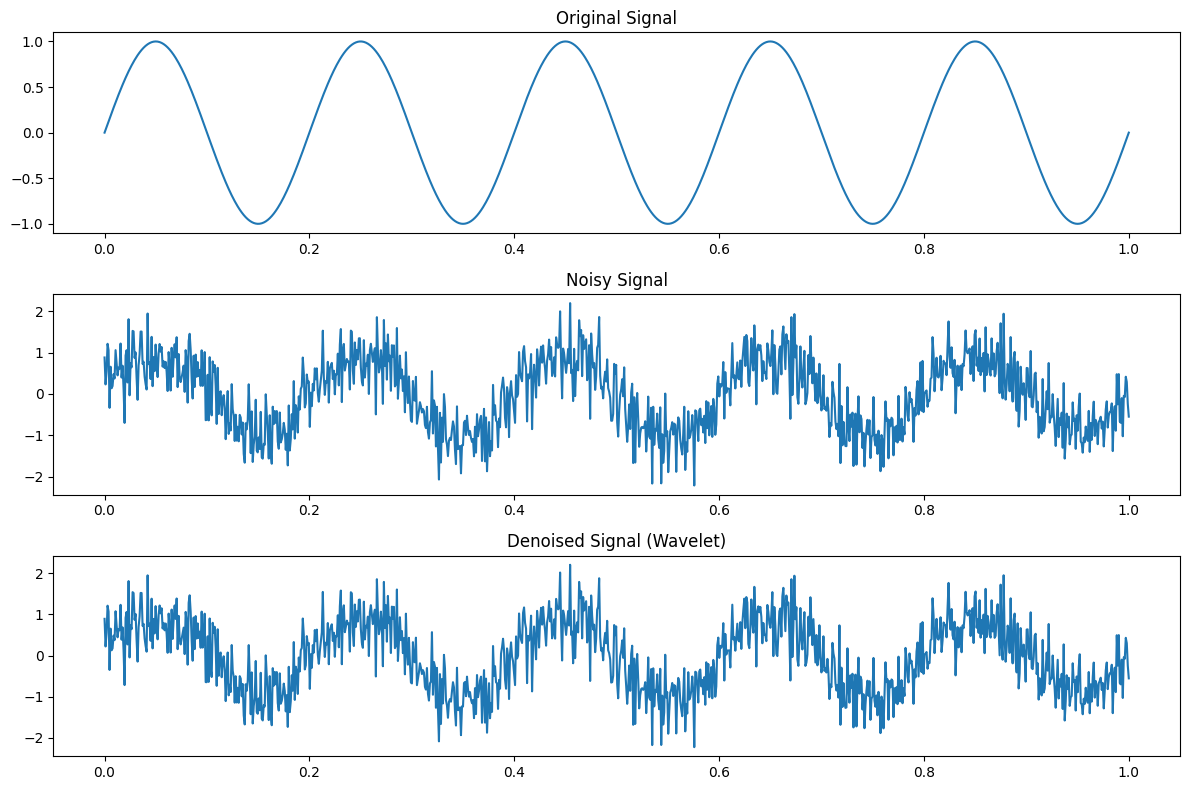

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 1. Generate a test signal (sine + noise)
np.random.seed(0)
t = np.linspace(0, 1, 1024)
signal = np.sin(2 * np.pi * 5 * t)  # clean signal
noise = np.random.normal(0, 0.5, t.shape)
noisy_signal = signal + noise

# 2. Apply Discrete Wavelet Transform
wavelet = 'db4'
coeffs = pywt.wavedec(noisy_signal, wavelet, level=4)

# coeffs structure:
# coeffs[0] = approximation
# coeffs[1:] = detail coefficients

# 3. Denoising (thresholding)
threshold = -0.01
denoised_coeffs = [coeffs[0]]  # keep approximation

for c in coeffs[1:]:
    denoised_coeffs.append(pywt.threshold(c, threshold, mode='soft'))

# 4. Reconstruct signal
denoised_signal = pywt.waverec(denoised_coeffs, wavelet)

# 5. Plot results
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.title("Original Signal")
plt.plot(t, signal)

plt.subplot(3, 1, 2)
plt.title("Noisy Signal")
plt.plot(t, noisy_signal)

plt.subplot(3, 1, 3)
plt.title("Denoised Signal (Wavelet)")
plt.plot(t, denoised_signal)

plt.tight_layout()
plt.show()


Simple wavelet decomposition

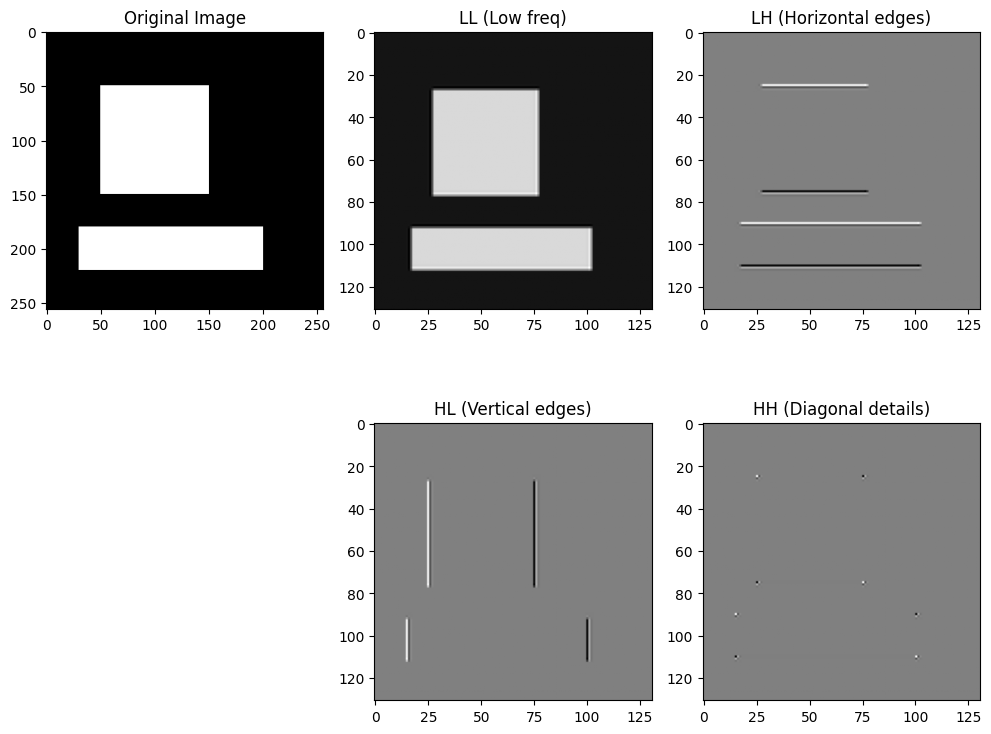

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 1. Create a simple binary image
img = np.zeros((256, 256))

# Add shapes (localized features)
img[50:150, 50:150] = 1      # square
img[180:220, 30:200] = 1     # horizontal bar

# 2. Apply 2D Wavelet Transform
wavelet = 'db4'
LL, (LH, HL, HH) = pywt.dwt2(img, wavelet)

# 3. Plot results
plt.figure(figsize=(10, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')

plt.subplot(2, 3, 2)
plt.title("LL (Low freq)")
plt.imshow(LL, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("LH (Horizontal edges)")
plt.imshow(LH, cmap='gray')

plt.subplot(2, 3, 5)
plt.title("HL (Vertical edges)")
plt.imshow(HL, cmap='gray')

plt.subplot(2, 3, 6)
plt.title("HH (Diagonal details)")
plt.imshow(HH, cmap='gray')

plt.tight_layout()
plt.show()


hierarchical wavelet decomposition

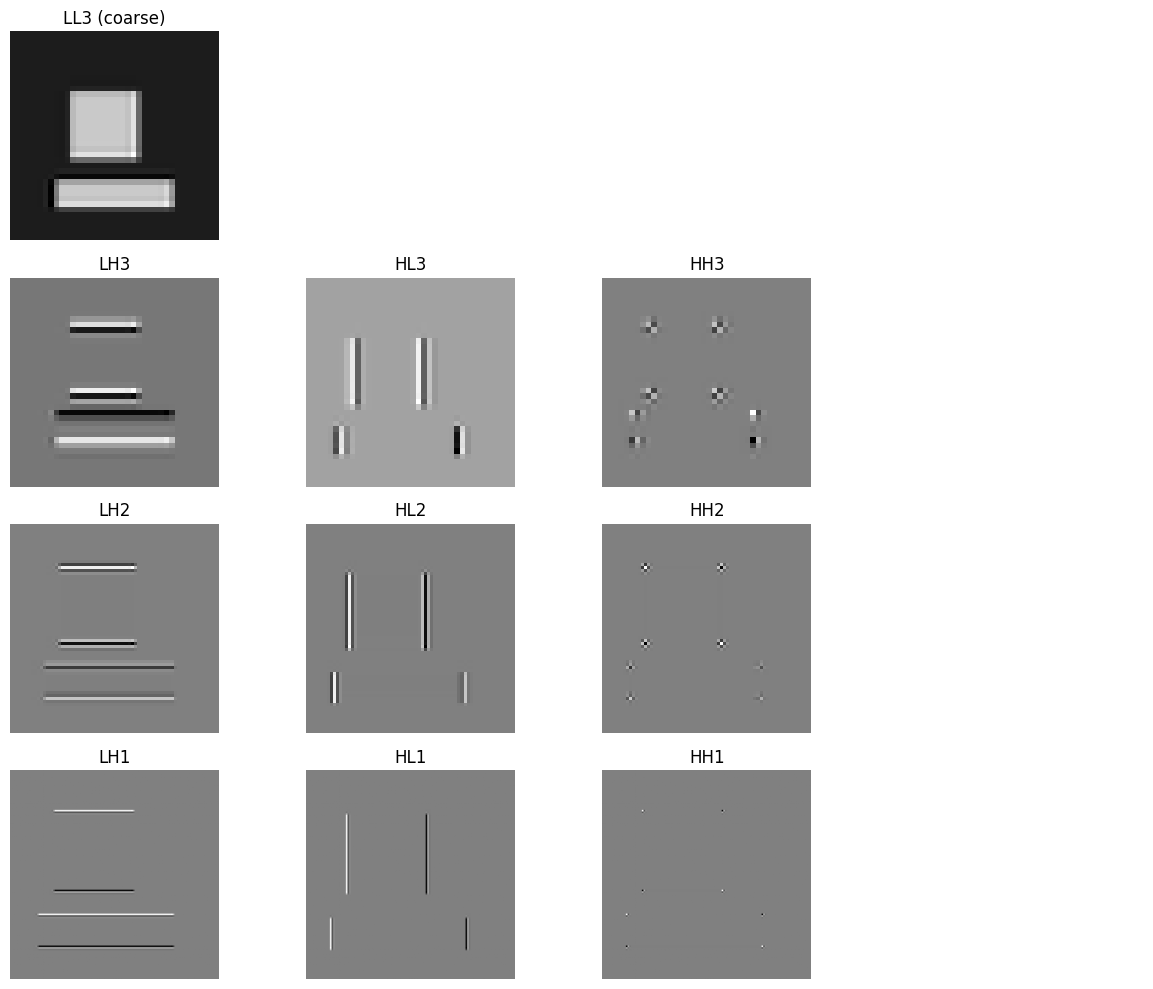

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 1. Create binary image (same as before)
img = np.zeros((256, 256))
img[50:150, 50:150] = 1
img[180:220, 30:200] = 1

# 2. Multi-level decomposition
wavelet = 'db4'
levels = 3
coeffs = pywt.wavedec2(img, wavelet, level=levels)

# coeffs structure:
# coeffs[0] = LL3
# coeffs[1] = (LH3, HL3, HH3)
# coeffs[2] = (LH2, HL2, HH2)
# coeffs[3] = (LH1, HL1, HH1)

# 3. Plot hierarchical decomposition
fig, axes = plt.subplots(levels + 1, 4, figsize=(12, 10))

# Top row → LL (final approximation)
axes[0, 0].imshow(coeffs[0], cmap='gray')
axes[0, 0].set_title("LL3 (coarse)")
axes[0, 0].axis('off')

# Empty slots for alignment
for i in range(1, 4):
    axes[0, i].axis('off')

# Plot each level
for i in range(levels):
    LH, HL, HH = coeffs[i + 1]

    axes[i + 1, 0].imshow(LH, cmap='gray')
    axes[i + 1, 0].set_title(f"LH{levels-i}")

    axes[i + 1, 1].imshow(HL, cmap='gray')
    axes[i + 1, 1].set_title(f"HL{levels-i}")

    axes[i + 1, 2].imshow(HH, cmap='gray')
    axes[i + 1, 2].set_title(f"HH{levels-i}")

    axes[i + 1, 3].axis('off')

    for j in range(3):
        axes[i + 1, j].axis('off')

plt.tight_layout()
plt.show()
